In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("shipments.csv")

print("Dataset loaded successfully")
print(df.shape)

Dataset loaded successfully
(19205, 11)


In [2]:
df.head()

,shipment_id,order_id,warehouse_city,delivery_city,shipping_method,dispatch_date,expected_delivery_date,actual_delivery_date,delivery_days,delivery_status,delayed_flag
0,SHIP1000001,ORD1000002,Mumbai,Nagpur,Economy/Surface,2024-12-15,2024-12-23,2024-12-26,11.0,Delivered,1
1,SHIP1000009,ORD1000014,Hyderabad,Vijayawada,Express,2023-07-22,2023-07-24,2023-07-23,1.0,Delivered,0
2,SHIP1000015,ORD1000020,Mumbai,Nagpur,Same-Day,2023-09-23,2023-09-23,2023-09-27,4.0,Delivered,1
3,SHIP1000017,ORD1000022,Ahmedabad,Ahmedabad,Standard,2024-11-24,2024-11-28,2024-11-29,5.0,Delivered,1
4,SHIP1000018,ORD1000023,Mumbai,Mumbai,Express,2025-10-29,2025-10-31,2025-10-31,2.0,Delivered,0


In [7]:
df.columns

Index(['shipment_id', 'order_id', 'warehouse_city', 'delivery_city',
       'shipping_method', 'dispatch_date', 'expected_delivery_date',
       'actual_delivery_date', 'delivery_days', 'delivery_status',
       'delayed_flag'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19205 entries, 0 to 19204
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   shipment_id             19205 non-null  object 
 1   order_id                19205 non-null  object 
 2   warehouse_city          19205 non-null  object 
 3   delivery_city           19205 non-null  object 
 4   shipping_method         19205 non-null  object 
 5   dispatch_date           19205 non-null  object 
 6   expected_delivery_date  19205 non-null  object 
 7   actual_delivery_date    18693 non-null  object 
 8   delivery_days           18693 non-null  float64
 9   delivery_status         19205 non-null  object 
 10  delayed_flag            19205 non-null  int64  
dtypes: float64(1), int64(1), object(9)
memory usage: 1.6+ MB


In [12]:
df.describe()

,delivery_days,delayed_flag
count,18693.000000,19205.000000
mean,4.080458,0.418329
std,2.506198,0.493298
min,0.000000,0.000000
25%,2.000000,0.000000
50%,4.000000,0.000000
75%,6.000000,1.000000
max,14.000000,1.000000


In [13]:
df.isna().sum()

shipment_id                 0
order_id                    0
warehouse_city              0
delivery_city               0
shipping_method             0
dispatch_date               0
expected_delivery_date      0
actual_delivery_date      512
delivery_days             512
delivery_status             0
delayed_flag                0
dtype: int64

In [14]:
df.isna().sum().sum()

1024

In [15]:
df.shipping_method.value_counts()

shipping_method
Standard           8606
Express            3915
Next-Day           2927
Economy/Surface    2790
Same-Day            967
Name: count, dtype: int64

In [16]:
missing_report = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": df.isnull().mean() * 100
})

missing_report.sort_values(
    "Missing_Count",
    ascending=False
)

,Missing_Count,Missing_Percentage
actual_delivery_date,512,2.665972
delivery_days,512,2.665972
shipment_id,0,0.000000
order_id,0,0.000000
warehouse_city,0,0.000000
delivery_city,0,0.000000
shipping_method,0,0.000000
dispatch_date,0,0.000000
expected_delivery_date,0,0.000000
delivery_status,0,0.000000


In [ ]:
"""
This is likely meaningful missing data.

These shipments were **cancelled** before delivery, so they don't have:

1.actual_delivery_date
2.delivery_days

"""

In [18]:
df.duplicated().sum()

0

In [20]:
df["shipment_id"].duplicated().sum()

0

In [21]:
df["order_id"].duplicated().sum()

0

In [22]:
df.dtypes

shipment_id                object
order_id                   object
warehouse_city             object
delivery_city              object
shipping_method            object
dispatch_date              object
expected_delivery_date     object
actual_delivery_date       object
delivery_days             float64
delivery_status            object
delayed_flag                int64
dtype: object

In [23]:
# WE have to convert the dtype of date column to date
date_columns = [
    "dispatch_date",
    "expected_delivery_date",
    "actual_delivery_date"
]

for col in date_columns:
    df[col] = pd.to_datetime(
        df[col],
        errors="coerce"
    )

In [24]:
df.dtypes

shipment_id                       object
order_id                          object
warehouse_city                    object
delivery_city                     object
shipping_method                   object
dispatch_date             datetime64[ns]
expected_delivery_date    datetime64[ns]
actual_delivery_date      datetime64[ns]
delivery_days                    float64
delivery_status                   object
delayed_flag                       int64
dtype: object

In [25]:
# Cleaning the Text values if any spaces are presented in that :
text_columns = df.select_dtypes(
    include="object"
).columns

for col in text_columns:
    df[col] = df[col].str.strip()

In [27]:
df.head()

,shipment_id,order_id,warehouse_city,delivery_city,shipping_method,dispatch_date,expected_delivery_date,actual_delivery_date,delivery_days,delivery_status,delayed_flag
0,SHIP1000001,ORD1000002,Mumbai,Nagpur,Economy/Surface,2024-12-15,2024-12-23,2024-12-26,11.0,Delivered,1
1,SHIP1000009,ORD1000014,Hyderabad,Vijayawada,Express,2023-07-22,2023-07-24,2023-07-23,1.0,Delivered,0
2,SHIP1000015,ORD1000020,Mumbai,Nagpur,Same-Day,2023-09-23,2023-09-23,2023-09-27,4.0,Delivered,1
3,SHIP1000017,ORD1000022,Ahmedabad,Ahmedabad,Standard,2024-11-24,2024-11-28,2024-11-29,5.0,Delivered,1
4,SHIP1000018,ORD1000023,Mumbai,Mumbai,Express,2025-10-29,2025-10-31,2025-10-31,2.0,Delivered,0


In [29]:
# 1.Validate shipping methods
df.shipping_method.value_counts()

shipping_method
Standard           8606
Express            3915
Next-Day           2927
Economy/Surface    2790
Same-Day            967
Name: count, dtype: int64

In [32]:
df.shipping_method.value_counts()/len(df.shipping_method)*100
# Standard shipping is the dominant shipping method, accounting for approximately 44.81% of shipments

shipping_method
Standard           44.811247
Express            20.385316
Next-Day           15.240823
Economy/Surface    14.527467
Same-Day            5.035147
Name: count, dtype: float64

In [33]:
# 2. Validating Delivery status
df["delivery_status"].value_counts()

delivery_status
Delivered                  17261
Delivered then Returned     1432
Cancelled in Transit         512
Name: count, dtype: int64

In [34]:
df["delivery_status"].value_counts()/len(df.delivery_status)*100

delivery_status
Delivered                  89.877636
Delivered then Returned     7.456392
Cancelled in Transit        2.665972
Name: count, dtype: float64

In [35]:
# 3.Validate delayed_flag
df["delayed_flag"].value_counts()

delayed_flag
0    11171
1     8034
Name: count, dtype: int64

In [43]:
round(df['delayed_flag'].value_counts()/len(df.delayed_flag)*100)
    # Almost 42% of shipments were delayed.

delayed_flag
0    58.0
1    42.0
Name: count, dtype: float64

In [53]:
# 4.Checking invalid delivery days
df[df["delivery_days"] <0]

,shipment_id,order_id,warehouse_city,delivery_city,shipping_method,dispatch_date,expected_delivery_date,actual_delivery_date,delivery_days,delivery_status,delayed_flag


In [54]:
(df["delivery_days"] == 0).sum()  # THis are  same day delivery days..


407

In [55]:
# 5 . Date validation
df[ df["expected_delivery_date"] < df["dispatch_date"] ]

,shipment_id,order_id,warehouse_city,delivery_city,shipping_method,dispatch_date,expected_delivery_date,actual_delivery_date,delivery_days,delivery_status,delayed_flag


In [56]:
df[df["actual_delivery_date"] < df["dispatch_date"]]

,shipment_id,order_id,warehouse_city,delivery_city,shipping_method,dispatch_date,expected_delivery_date,actual_delivery_date,delivery_days,delivery_status,delayed_flag


In [57]:
calculated_delay = (
    df["actual_delivery_date"] >
    df["expected_delivery_date"]
).astype(int)

comparison = (
    calculated_delay != df["delayed_flag"]
)

print(comparison.sum())

0


In [60]:
calculated_delivery_days = (
    df["actual_delivery_date"] -
    df["dispatch_date"]
).dt.days

In [62]:
calculated_delivery_days

0        11.0
1         1.0
2         4.0
3         5.0
4         2.0
         ... 
19200     NaN
19201     6.0
19202     6.0
19203     4.0
19204     1.0
Length: 19205, dtype: float64

In [61]:
difference = (
    df["delivery_days"] -
    calculated_delivery_days
)

difference.abs().gt(0).sum()

179

In [66]:
# 179 records have a delivery_days value that does not exactly match the date difference.

In [63]:
df["delivery_days_validation"] = np.where(
    df["delivery_days"].notna() &
    df["actual_delivery_date"].notna() &
    (df["delivery_days"] != calculated_delivery_days),
    "Review",
    "Valid"
)

In [65]:
df.delivery_days_validation.value_counts()

delivery_days_validation
Valid     19026
Review      179
Name: count, dtype: int64

In [74]:
days_to_delivery= df["delivery_days"].value_counts()
print(days_to_delivery)
print("Maximum days taken to delivery:", df['delivery_days'].max())
print("Minimum days taken to delivery:", df['delivery_days'].min()) # same day delivery 

delivery_days
3.0     3135
1.0     2836
5.0     2591
6.0     2580
2.0     2465
4.0     2063
7.0      709
8.0      645
9.0      606
10.0     521
0.0      407
11.0      56
12.0      31
13.0      29
14.0      19
Name: count, dtype: int64
Maximum days taken to delivery: 14.0
Minimum days taken to delivery: 0.0


In [76]:
# Outlier detection

Q1 = df["delivery_days"].quantile(0.25)
Q3 = df["delivery_days"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower:", lower_bound)              #Maximum days taken to delivery: 14.0
                                          #Minimum days taken to delivery: 0.0
print("Upper:", upper_bound)

Lower: -4.0
Upper: 12.0


<Axes: xlabel='delivery_days'>

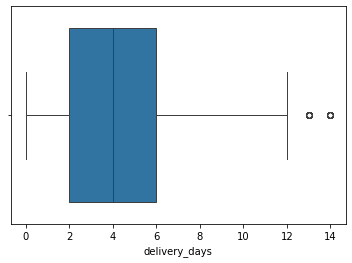

In [80]:
import seaborn as sns
sns.boxplot(data=df ,x="delivery_days")
#A 13- or 14-day shipment can be a legitimate delayed shipment.

In [89]:
outliers = df[ (df["delivery_days"] <lower_bound ) | (df["delivery_days"] >upper_bound )]
outliers.head() # 48


,shipment_id,order_id,warehouse_city,delivery_city,shipping_method,dispatch_date,expected_delivery_date,actual_delivery_date,delivery_days,delivery_status,delayed_flag,delivery_days_validation
120,SHIP1000567,ORD1000642,Hyderabad,Visakhapatnam,Economy/Surface,2023-04-03,2023-04-11,2023-04-16,13.0,Delivered,1,Valid
315,SHIP1001508,ORD1001691,Mumbai,Pune,Economy/Surface,2025-11-19,2025-11-27,2025-12-02,13.0,Delivered,1,Valid
808,SHIP1003844,ORD1004312,Ahmedabad,Ahmedabad,Economy/Surface,2025-12-07,2025-12-15,2025-12-20,13.0,Delivered,1,Valid
862,SHIP1004132,ORD1004639,Chennai,Kochi,Economy/Surface,2025-12-22,2025-12-30,2025-12-31,14.0,Delivered,1,Review
1613,SHIP1007525,ORD1008425,Delhi-NCR (Gurugram),Noida,Economy/Surface,2025-08-24,2025-09-01,2025-09-06,13.0,Delivered,1,Valid


In [96]:

method_analysis = df.groupby(
    "shipping_method"
).agg(
    shipments=("shipment_id", "count"),
    average_delivery_days=("delivery_days", "mean"),
    median_delivery_days=("delivery_days", "median"),
    delay_rate=("delayed_flag", "mean")
).sort_values(
    "shipments",
    ascending=False
)

# 2. Apply rounding and formatting fixes
method_analysis["average_delivery_days"] = method_analysis["average_delivery_days"].round(1)
method_analysis["median_delivery_days"] = method_analysis["median_delivery_days"].astype(int)
method_analysis["delay_rate"] = method_analysis["delay_rate"].map(lambda x: f"{x:.1%}")


method_analysis


,shipments,average_delivery_days,median_delivery_days,delay_rate
shipping_method,,,,
Standard,8606,4.8,5,53.9%
Express,3915,2.3,2,37.8%
Next-Day,2927,1.8,2,11.3%
Economy/Surface,2790,7.8,8,37.5%
Same-Day,967,0.8,1,56.0%


In [99]:

warehouse_analysis = df.groupby(
    "warehouse_city"
).agg(
    shipments=("shipment_id", "count"),
    delay_rate=("delayed_flag", "mean"),
    average_delivery_days=("delivery_days", "mean")
).sort_values(
    "shipments",
    ascending=False
)

warehouse_analysis["average_delivery_days"] = warehouse_analysis["average_delivery_days"].round(1)
warehouse_analysis["delay_rate"] = warehouse_analysis["delay_rate"].map(lambda x: f"{x:.1%}")

# 3. Display the final DataFrame
warehouse_analysis

"""
Delhi-NCR (Gurugram) is the largest shipment origin, handling 4,926 shipments.
But its delay rate is around 42.14%, which is close to the overall rate.
"""

,shipments,delay_rate,average_delivery_days
warehouse_city,,,
Delhi-NCR (Gurugram),4926,42.1%,4.1
Mumbai,3579,42.3%,4.1
Ahmedabad,2911,42.3%,4.1
Chennai,2567,42.3%,4.1
Hyderabad,2259,39.8%,4.1
Bengaluru,1555,41.0%,4.1
Kolkata,1408,42.0%,4.0


In [103]:
route_analysis = df.groupby(
    ["warehouse_city", "delivery_city"]
).agg(
    shipments=("shipment_id", "count"),
    delay_rate=("delayed_flag", "mean"),
    average_delivery_days=("delivery_days", "mean")   #The highest-volume route is:
                                                       #Mumbai → Pune: 919 shipments 
).sort_values(  
    "shipments",
    ascending=False
)

route_analysis.head(15)

shipments  delay_rate  \
warehouse_city       delivery_city                          
Mumbai               Pune                 919    0.410229   
Delhi-NCR (Gurugram) New Delhi            906    0.417219   
Mumbai               Nagpur               901    0.432852   
                     Mumbai               868    0.414747   
Bengaluru            Mysuru               789    0.401774   
Chennai              Chennai              777    0.437580   
                     Coimbatore           772    0.397668   
Bengaluru            Bengaluru            766    0.419060   
Ahmedabad            Ahmedabad            721    0.418863   
Delhi-NCR (Gurugram) Lucknow              706    0.399433   
Hyderabad            Warangal             683    0.390922   
Delhi-NCR (Gurugram) Noida                677    0.446086   
                     Kanpur               637    0.422292   
Ahmedabad            Surat                637    0.419152   
                     Vadodara             634    0.446372   

                                    average_delivery_days  
warehouse_city       delivery_city                         
Mumbai               Pune                        4.101336  
Delhi-NCR (Gurugram) New Delhi                   4.037628  
Mumbai               Nagpur                      3.977169  
                     Mumbai                      4.163701  
Bengaluru            Mysuru                      4.076723  
Chennai              Chennai                     4.110526  
                     Coimbatore                  3.992074  
Bengaluru            Bengaluru                   4.103774  
Ahmedabad            Ahmedabad                   4.193687  
Delhi-NCR (Gurugram) Lucknow                     4.036337  
Hyderabad            Warangal                    4.071964  
Delhi-NCR (Gurugram) Noida                       4.173252  
                     Kanpur                      4.054313  
Ahmedabad            Surat                       4.038772  
                     Vadodara                    4.013051

In [105]:
# same city shipments 
same_city = (
    df["warehouse_city"] ==
    df["delivery_city"]
)

same_city.sum()

4270

In [107]:
s =df[(df["warehouse_city"] ==df["delivery_city"])]
s

,shipment_id,order_id,warehouse_city,delivery_city,shipping_method,dispatch_date,expected_delivery_date,actual_delivery_date,delivery_days,delivery_status,delayed_flag,delivery_days_validation
3,SHIP1000017,ORD1000022,Ahmedabad,Ahmedabad,Standard,2024-11-24,2024-11-28,2024-11-29,5.0,Delivered,1,Valid
4,SHIP1000018,ORD1000023,Mumbai,Mumbai,Express,2025-10-29,2025-10-31,2025-10-31,2.0,Delivered,0,Valid
5,SHIP1000019,ORD1000024,Chennai,Chennai,Express,2024-04-24,2024-04-26,2024-04-25,1.0,Delivered,0,Valid
6,SHIP1000027,ORD1000032,Hyderabad,Hyderabad,Economy/Surface,2023-05-07,2023-05-15,2023-05-14,7.0,Delivered,0,Valid
11,SHIP1000063,ORD1000077,Hyderabad,Hyderabad,Express,2023-07-21,2023-07-23,2023-07-23,2.0,Delivered,0,Valid
...,...,...,...,...,...,...,...,...,...,...,...,...
19190,SHIP1089615,ORD1099922,Hyderabad,Hyderabad,Express,2023-11-05,2023-11-07,2023-11-06,1.0,Delivered,0,Valid
19193,SHIP1089630,ORD1099938,Mumbai,Mumbai,Next-Day,2023-08-09,2023-08-11,2023-08-11,2.0,Delivered then Returned,0,Valid
19198,SHIP1089654,ORD1099967,Hyderabad,Hyderabad,Standard,2024-11-15,2024-11-19,2024-11-19,4.0,Delivered,0,Valid
19201,SHIP1089659,ORD1099974,Ahmedabad,Ahmedabad,Standard,2023-08-29,2023-09-02,2023-09-04,6.0,Delivered,1,Valid


In [108]:
df.to_csv(
    "shipments_cleaned.csv",
    index=False
)
